In [1]:
import pandas as pd
import numpy as np
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
from sklearn.impute import KNNImputer
import warnings
warnings.filterwarnings("ignore")

In [2]:
%load_ext autoreload
%autoreload 2

In [ ]:
path_dna甲基化 = '' 
path_基因表达 = ''
path_拷贝数变化 = ''
path_临床数据 = ''

In [4]:
df_dna甲基化 = pd.read_csv(path_dna甲基化)
df_基因表达 = pd.read_csv(path_基因表达)
df_拷贝数变化 = pd.read_csv(path_拷贝数变化)
df_临床 = pd.read_csv(path_临床数据)

In [5]:
print(sum(df_基因表达['Patient ID'] == df_dna甲基化['Patient ID']))
print(sum(df_拷贝数变化['Patient ID'] == df_dna甲基化['Patient ID']))
print(sum(df_临床['Patient ID'] == df_dna甲基化['Patient ID']))

1079
1079
1079


In [6]:
y = df_dna甲基化['cancer_status']

In [7]:
print(df_dna甲基化.shape,df_拷贝数变化.shape,df_基因表达.shape,df_临床.shape)
print(df_dna甲基化.shape[1]+df_拷贝数变化.shape[1]+df_基因表达.shape[1]+df_临床.shape[1]) #包含病人ID和复发标签

(1079, 820) (1079, 86) (1079, 374) (1079, 32)
1312


In [8]:
df_dna甲基化 = df_dna甲基化.iloc[:,1:819]
df_拷贝数变化 = df_拷贝数变化.iloc[:,1:85]
df_基因表达 = df_基因表达.iloc[:,1:373]
df_临床 = df_临床.iloc[:,1:]

In [9]:
# 找出x中类型为object的列
tmp = df_临床[df_临床.columns[df_临床.dtypes == 'object']]

In [10]:
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

labelEncoder_dict = {}

# 对多个列进行编码
for col in tmp.columns:
    le = LabelEncoder()
    tmp[col] = le.fit_transform(tmp[col])
    labelEncoder_dict[col] = le
tmp.head()
df_临床[df_临床.columns[df_临床.dtypes == 'object']] = tmp

In [11]:
y = y.replace({'WITH TUMOR': 1, 'TUMOR FREE': 0})

In [12]:
y.value_counts()

0    730
1    349
Name: cancer_status, dtype: int64

In [13]:
df_拷贝数变化.shape

(1079, 84)

In [14]:
print(df_dna甲基化.shape,df_拷贝数变化.shape,df_基因表达.shape,df_临床.shape)
print(df_dna甲基化.shape[1]+df_拷贝数变化.shape[1]+df_基因表达.shape[1]+df_临床.shape[1])

(1079, 818) (1079, 84) (1079, 372) (1079, 31)
1305


In [15]:
# 假设每个组学的数据存储在字典中，键为组学名，值为DataFrame
omics_data = {
    'dna甲基化': df_dna甲基化,
    '拷贝数变化': df_拷贝数变化,
    '基因表达': df_基因表达,
    '临床': df_临床
}

# 处理每个组学数据，填充缺失值,不填充缺失值无法画图
omics_data_knn = {}
for name, df in omics_data.items():
    cols = df.columns
    # 填充缺失值
    imputer = KNNImputer(n_neighbors=10)
    df = imputer.fit_transform(df)
    df = pd.DataFrame(df,columns=cols)

    omics_data_knn[name] = df

In [16]:
# 处理每个组学数据，标准化
processed_omics = {}
for name, df in omics_data_knn.items():
    # 标准化
    scaler = StandardScaler()
    scaled_df = scaler.fit_transform(df)

    processed_omics[name] = scaled_df

In [17]:
# 设置随机种子保证可复现性(CPU版本)
import torch
import torch.nn as nn
import random

# 设置全局随机种子
seed = 43

# Python & NumPy
random.seed(seed)    # Python内置random模块
np.random.seed(seed) # NumPy随机数生成器

# PyTorch的随机种子设置（同时适用于CPU和GPU）
torch.manual_seed(seed)       # CPU随机种子

In [ ]:
# 获取每个组学的特征数
feature_dims = [df_dna甲基化.shape[1], df_拷贝数变化.shape[1], df_基因表达.shape[1],  df_临床.shape[1]]

# 将数据拼接为 (1079, 4, 最大特征数)
max_features = max(feature_dims)
data = np.zeros((1079, 4, max_features))  # 初始化数组

# 填充数据
data[:, 0, :feature_dims[0]] = processed_omics['dna甲基化']
data[:, 1, :feature_dims[1]] = processed_omics['拷贝数变化']
data[:, 2, :feature_dims[2]] = processed_omics['基因表达']
data[:, 3, :feature_dims[3]] = processed_omics['临床']
# 填充后的数据就是 1079 4 最大特征数 4各组学的特征数，没有数据的部分补充为0，
# 这样数据为 0 的部分就可以忽略不计，算法也可以处理，这样都不需要降维

In [19]:
data[:,0,:feature_dims[0]].shape  # 第一个组学数据的特征维度

(1079, 818)

In [20]:
X_train, X_test, y_train, y_test = train_test_split(data, y.to_numpy().flatten(), test_size=0.2, random_state=seed)

In [21]:
X_train[:,0,:feature_dims[0]].shape

(863, 818)

In [22]:
# 转换为 PyTorch 张量
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

In [23]:
from torch.utils.data import DataLoader, TensorDataset

# 创建数据集
train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

# 创建数据加载器 训练集打乱，打乱顺序使用随机数种子保证可复现
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [ ]:
from multi_omics_net import MultiOmicsNet
from multi_omics_net import huatu
from multi_omics_net import display_performance

In [25]:
def train(train_loader, X_test, y_test):

    # 初始化模型
    model = MultiOmicsNet(
    n_omics=4,
    d_model=128, #128 64  Transformer编码器输入输出维度
    nhead=4,
    dim_feedforward=256, #512
    dropout=0.5,
    input_dims=[feature_dims[0],feature_dims[1],feature_dims[2],feature_dims[3]]
    )   # 各组的原始特征维度


    # 训练配置
    criterion = nn.BCEWithLogitsLoss()


    # 获取除最后一层外的所有参数
    base_params = [param for name, param in model.named_parameters() 
                  if not name.startswith("logits_predictor.")]
    # 训练配置，最后一层使用10倍学习率
    optimizer = torch.optim.Adam([
        {'params': base_params},
        {'params': model.logits_predictor.parameters(), 'lr': 1e-3}  # 最后一层使用10倍学习率
    ], lr=1e-4,)  # 基础学习率

    # optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
    # 学习率调度器，使用余弦衰减学习率,T_max=100
    # 如果验证集性能在某个epoch后不再提升，可以将T_max设置为该epoch数，以加速收敛。
    # scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=100)


    train_losses = []
    test_losses = []
    test_accuracies = []
    test_aucs = []

    import copy
    best_epoch = 0
    max_auc = 0
    best_model = None

    # 训练循环
    for epoch in range(30):  
        model.train()
        train_loss = 0
        for x, y in train_loader: #每个batch 32 个样本
            optimizer.zero_grad()
            pred = model(
                [
                x[:, 0, :feature_dims[0]],
                x[:, 1, :feature_dims[1]],
                x[:, 2, :feature_dims[2]],
                x[:, 3, :feature_dims[3]]
                ]
            )[0].squeeze()

            loss = criterion(pred, y) # BCEWithLogitsLoss 结合了 sigmoid 和 BCELoss 
            train_loss += loss.item() #累记训练损失
            loss.backward() #反向传播
            optimizer.step() #更新网络中的参数
            # scheduler.step()  # 更新学习率

        train_losses.append(train_loss)

        # 评估
        test_loss = 0
        test_accuracy = 0
        test_auc = 0
        model.eval()
        with torch.no_grad():
            # 计算测试损失
            pred_probability,attn_weights_list_all_omics,encoded_features,features = model(
                [
                X_test[:, 0, :feature_dims[0]],
                X_test[:, 1, :feature_dims[1]],
                X_test[:, 2, :feature_dims[2]],
                X_test[:, 3, :feature_dims[3]]
                ]
            )
            test_loss = criterion(pred_probability.squeeze(), y_test)
            test_losses.append(test_loss.item())

            # 此处使用sigmoid函数 将 输出转换为概率，方便计算AUC，准确率
            y_pred_proba = torch.sigmoid(pred_probability).detach().numpy()
            y_pred = (y_pred_proba > 0.5).astype(int)

            # 计算测试准确率
            test_accuracy = accuracy_score(y_test.numpy(), y_pred)
            test_accuracies.append(test_accuracy)

            # 计算AUC
            test_auc = roc_auc_score(y_test.numpy(), y_pred_proba)
            test_aucs.append(test_auc)

            # 保存最佳模型
            if test_auc > max_auc:
                if test_loss < train_loss: #未过拟合
                    best_epoch = epoch + 1
                    max_auc = test_auc
                    best_model = copy.deepcopy(model)

        print(f"Epoch {epoch+1},Train Loss: {train_loss:.4f},Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}, Test AUC: {test_auc:.4f}")

    print(f"Best Epoch: {best_epoch}, Best AUC: {max_auc:.4f}") 

    return best_model, train_losses, test_losses, test_accuracies, test_aucs

Epoch 1,Train Loss: 17.2352,Test Loss: 0.6298, Test Accuracy: 0.6759, Test AUC: 0.6220
Epoch 2,Train Loss: 16.9468,Test Loss: 0.6295, Test Accuracy: 0.6759, Test AUC: 0.6737
Epoch 3,Train Loss: 16.9740,Test Loss: 0.6502, Test Accuracy: 0.6759, Test AUC: 0.6905
Epoch 4,Train Loss: 17.1657,Test Loss: 0.6294, Test Accuracy: 0.6759, Test AUC: 0.7005
Epoch 5,Train Loss: 16.9748,Test Loss: 0.6299, Test Accuracy: 0.6759, Test AUC: 0.7195
Epoch 6,Train Loss: 16.9315,Test Loss: 0.6249, Test Accuracy: 0.6759, Test AUC: 0.7259
Epoch 7,Train Loss: 16.7961,Test Loss: 0.6159, Test Accuracy: 0.6759, Test AUC: 0.7308
Epoch 8,Train Loss: 16.7331,Test Loss: 0.5989, Test Accuracy: 0.6759, Test AUC: 0.7509
Epoch 9,Train Loss: 15.7860,Test Loss: 0.5538, Test Accuracy: 0.7222, Test AUC: 0.7824
Epoch 10,Train Loss: 14.0730,Test Loss: 0.5219, Test Accuracy: 0.7546, Test AUC: 0.8361
Epoch 11,Train Loss: 10.4816,Test Loss: 0.3761, Test Accuracy: 0.8426, Test AUC: 0.9164
Epoch 12,Train Loss: 5.3162,Test Loss: 0.

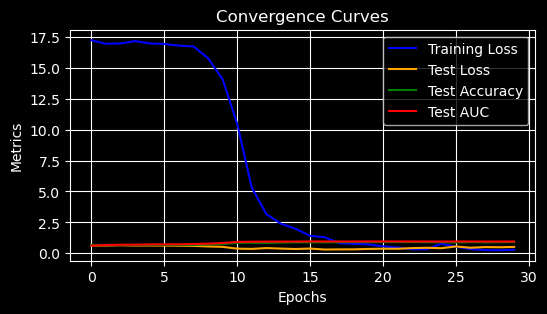

Accuracy: 0.91
AUC: 0.96
敏感性: 0.76
特异性: 0.98
PPV: 0.95
NPV: 0.89


In [26]:
# del best_model
best_model,train_losses,test_losses,test_accuracies,test_aucs = train(train_loader,X_test,y_test)
huatu(train_losses,test_losses,test_accuracies,test_aucs)
display_performance(best_model,X_test,y_test,feature_dims)  # 单次运行，结果受1.数据的分布 ; 2.模型参数默认初始化的影响

# Accuracy: 0.91
# AUC: 0.96
# 敏感性: 0.76
# 特异性: 0.98
# PPV: 0.95
# NPV: 0.89

In [27]:
# 保存best_model
# torch.save(best_model.state_dict(), 'model_weights.pth') # 保存模型参数
# torch.save(best_model, 'MultiOmicsNet.pth') # 保存整个模型

In [29]:
# 使用10折交叉验证，评价模型性能
from sklearn.model_selection import KFold
import pickle
import joblib

# 固定随机种子保证数据划分可复现
kf = KFold(n_splits=10, shuffle=True, random_state=seed)

omics_contributions_list = []
test_index_list = []  # 存储每折中，每个测试集的索引

y_test_list = []  #存储每折中 用于测试样本的真实标签
preds_list = []   #存储每折中 用于测试样本的预测标签
preds_proba_list = []  #存储每折中 用于测试样本的预测概率

omics_shap_values_all = []  #存储每折中 每个样本的每个omic的shap值累加和

encoded_features_list = [] # 模型训练好后，单个组学被编码器捕获的特征
features_list = []  # 模型训练好后，融合被捕获的特征再被编码器捕获的特征

for fold, (train_idx, test_idx) in enumerate(kf.split(data)):
    print(f"\n=== Fold {fold+1}/10 ===")

    tmp_y = y.to_numpy().flatten()

    # 划分训练集和验证集
    X_train, X_test = data[train_idx], data[test_idx]
    y_train, y_test = tmp_y[train_idx], tmp_y[test_idx]

    # 转换为 PyTorch 张量
    X_train = torch.tensor(X_train, dtype=torch.float32)
    X_test = torch.tensor(X_test, dtype=torch.float32)

    y_train = torch.tensor(y_train, dtype=torch.float32)
    y_test = torch.tensor(y_test, dtype=torch.float32)

    # 创建数据集
    train_dataset = TensorDataset(X_train, y_train)
    test_dataset = TensorDataset(X_test, y_test)

    # 创建数据加载器
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)


    best_model,train_losses,test_losses,test_accuracies,test_aucs = train(train_loader,X_test,y_test)
    # 保存模型
    joblib.dump(best_model, './saved_model/MoN_'+str(fold+1)+'.pkl')

    best_model.eval()
    with torch.no_grad():
        # 计算测试损失
        pred_probability,attn_weights_list_all_omics,encoded_features,features = best_model(
            [
                X_test[:, 0, :feature_dims[0]],
                X_test[:, 1, :feature_dims[1]],
                X_test[:, 2, :feature_dims[2]],
                X_test[:, 3, :feature_dims[3]]
            ]
        )
        
        # 此处使用sigmoid函数 将 输出转换为概率，方便计算AUC，准确率
        y_pred_proba = torch.sigmoid(pred_probability).detach().numpy()
        y_pred = (y_pred_proba > 0.5).astype(int).flatten()

        y_test_list = y_test_list + list(tmp_y[test_idx])  #存储每折中 用于测试样本的真实标签
        preds_list =  preds_list + list(y_pred) #存储每折中 用于测试样本的预测标签
        preds_proba_list =  preds_proba_list + list(y_pred_proba.flatten()) #存储每折中 用于测试样本的预测概率

        encoded_features_list.append(encoded_features) # 模型训练好后，单个组学被编码器捕获的特征
        features_list.append(features)  # 模型训练好后，融合被捕获的特征再被编码器捕获的特征

        combined_attn = torch.stack(attn_weights_list_all_omics)
        omics_contributions_list.append(combined_attn)
    
    test_index_list += list(test_idx)
    
    # 计算这一折的SHAP值
    omics_shap_values = calculate_shap_values(best_model,X_train,X_test,feature_dims)
    omics_shap_values_all.append(omics_shap_values)  # 12 minutes


=== Fold 1/10 ===
Epoch 1,Train Loss: 19.5803,Test Loss: 0.6939, Test Accuracy: 0.6389, Test AUC: 0.7187
Epoch 2,Train Loss: 19.5229,Test Loss: 0.6565, Test Accuracy: 0.6389, Test AUC: 0.7369
Epoch 3,Train Loss: 19.4211,Test Loss: 0.6597, Test Accuracy: 0.6389, Test AUC: 0.7202
Epoch 4,Train Loss: 19.4044,Test Loss: 0.6582, Test Accuracy: 0.6389, Test AUC: 0.7295
Epoch 5,Train Loss: 19.3512,Test Loss: 0.6604, Test Accuracy: 0.6389, Test AUC: 0.7302
Epoch 6,Train Loss: 19.5082,Test Loss: 0.6669, Test Accuracy: 0.6389, Test AUC: 0.7302
Epoch 7,Train Loss: 19.2198,Test Loss: 0.6557, Test Accuracy: 0.6389, Test AUC: 0.7399
Epoch 8,Train Loss: 18.7464,Test Loss: 0.6032, Test Accuracy: 0.6389, Test AUC: 0.7533
Epoch 9,Train Loss: 17.4797,Test Loss: 0.5829, Test Accuracy: 0.6759, Test AUC: 0.7860
Epoch 10,Train Loss: 15.4230,Test Loss: 0.5171, Test Accuracy: 0.7407, Test AUC: 0.8748
Epoch 11,Train Loss: 10.9175,Test Loss: 0.3473, Test Accuracy: 0.8889, Test AUC: 0.9279
Epoch 12,Train Loss: 6

In [30]:
len(test_index_list)
# len(y_test_list)
# len(preds_list)
# len(preds_proba_list)

1079

In [31]:
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,confusion_matrix

# 计算置信区间
def bootstrap_ci(y_true, y_pred, y_score=None, n_boot=2000, seed=42):
    rng = np.random.RandomState(seed)
    metrics = ["AUC","ACC","SENS","SPEC","PPV","NPV","F1"]
    results = {m: [] for m in metrics}

    for _ in range(n_boot):
        idx = rng.randint(0, len(y_true), len(y_true)) #随机抽取样本计算
        y_t = y_true[idx]
        y_p = y_pred[idx]
        y_s = y_score[idx] if y_score is not None else None

        # tn, fp, fn, tp = confusion_matrix(y_t, y_p).ravel()
        # results["ACC"].append((tp + tn) / (tp + tn + fp + fn))
        # results["SENS"].append(tp / (tp + fn) if (tp + fn) > 0 else np.nan)
        # results["SPEC"].append(tn / (tn + fp) if (tn + fp) > 0 else np.nan)
        # results["PPV"].append(tp / (tp + fp) if (tp + fp) > 0 else np.nan)
        # results["NPV"].append(tn / (tn + fn) if (tn + fn) > 0 else np.nan)
        # results["F1"].append(f1_score(y_t, y_p))
        
        # 反复抽样太多次，出现只有一个类别时，计算指标会报错
        # 检查是否只有一个类别
        unique_classes = np.unique(y_t)
        if len(unique_classes) == 1:
            # 只有一个类别时，所有指标设为NaN
            results["ACC"].append(np.nan)
            results["SENS"].append(np.nan)
            results["SPEC"].append(np.nan)
            results["PPV"].append(np.nan)
            results["NPV"].append(np.nan)
            results["F1"].append(np.nan)
        else:
            # 正常计算混淆矩阵
            tn, fp, fn, tp = confusion_matrix(y_t, y_p).ravel()
            results["ACC"].append((tp + tn) / (tp + tn + fp + fn))
            results["SENS"].append(tp / (tp + fn) if (tp + fn) > 0 else np.nan)
            results["SPEC"].append(tn / (tn + fp) if (tn + fp) > 0 else np.nan)
            results["PPV"].append(tp / (tp + fp) if (tp + fp) > 0 else np.nan)
            results["NPV"].append(tn / (tn + fn) if (tn + fn) > 0 else np.nan)
            results["F1"].append(f1_score(y_t, y_p))

        if y_s is not None:
            # results["AUC"].append(roc_auc_score(y_t, y_s))
            try:
                # 随机抽取的样本，可能只有一个类别，导致计算错误，检查是否只有一个类别
                if len(np.unique(y_t)) == 1:
                    results["AUC"].append(np.nan)
                else:
                    results["AUC"].append(roc_auc_score(y_t, y_s))
            except ValueError:
                # 处理roc_auc_score可能抛出的其他错误
                results["AUC"].append(np.nan)
        else:
            results["AUC"].append(np.nan)

    ci = {}
    for m in metrics:
        arr = np.array(results[m])
        ci[m] = {
            "mean": np.nanmean(arr),
            "low": np.nanpercentile(arr, 2.5),
            "high": np.nanpercentile(arr, 97.5)
        }

    return ci

# 计算性能
def calculate_metrics(y_true, y_scores, threshold=0.5):
    """
    计算二分类模型的评估指标
    
    Parameters:
    y_true: 真实标签 (0或1)
    y_scores: 预测概率或分数
    threshold: 分类阈值，默认为0.5
    
    Returns:
    dict: 包含所有评估指标的字典
    """
    # y_true = eval(y_true)
    # y_scores = eval(y_scores)
    # 转换为numpy数组确保正确处理
    y_true = np.array(y_true)
    y_scores = np.array(y_scores)

    # 将概率转换为预测标签
    y_pred = (y_scores >= threshold).astype(int)
    # 计算混淆矩阵
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    # 计算各个指标
    # 使用预测标签计算的AUC值可能不准确，这会导致模型性能评估出现偏差
    auc = round(roc_auc_score(y_true, y_scores),3) 
    acc = round(accuracy_score(y_true, y_pred),3)
    sens = round(recall_score(y_true, y_pred),3)  # 敏感性 = 召回率
    spec = round(tn / (tn + fp),3)  # 特异性
    ppv = round(precision_score(y_true, y_pred),3)  # 阳性预测值 = 精确率
    npv = round(tn / (tn + fn),3)  # 阴性预测值
    f1 = round(f1_score(y_true, y_pred),3)

    ci = bootstrap_ci(y_true, y_pred, y_scores, n_boot=1000, seed=42) # n_boot 超过1000以上
    
    # 处理NaN值的情况
    if np.isnan(auc):
        auc_ci = "(N/A)"
        # auc = "N/A"
    else:
        auc_ci = f"({ci['AUC']['low']:.3f}–{ci['AUC']['high']:.3f})"
        # auc = f"{auc:.3f}"

    # auc_ci = f"({ci['AUC']['low']:.3f}–{ci['AUC']['high']:.3f})"
    acc_ci = f"({ci['ACC']['low']:.3f}–{ci['ACC']['high']:.3f})"
    sens_ci = f"({ci['SENS']['low']:.3f}–{ci['SENS']['high']:.3f})"
    spec_ci = f"({ci['SPEC']['low']:.3f}–{ci['SPEC']['high']:.3f})"
    ppv_ci = f"({ci['PPV']['low']:.3f}–{ci['PPV']['high']:.3f})"
    npv_ci = f"({ci['NPV']['low']:.3f}–{ci['NPV']['high']:.3f})"
    f1_ci = f"({ci['F1']['low']:.3f}–{ci['F1']['high']:.3f})"
    
    # AUC = f"{auc:.3f}"+auc_ci if (auc != 1 and auc != 0) else f"{auc:.3f}"
    # ACC = f"{acc:.3f}"+acc_ci if (acc != 1 and acc != 0) else f"{acc:.3f}"
    # SENS = f"{sens:.3f}"+sens_ci if (sens != 1 and sens != 0) else f"{sens:.3f}"
    # SPEC = f"{spec:.3f}"+spec_ci if (spec != 1 and spec != 0) else f"{spec:.3f}"
    # PPV = f"{ppv:.3f}"+ppv_ci if (ppv != 1 and ppv != 0) else f"{ppv:.3f}"
    # NPV = f"{npv:.3f}"+npv_ci if (npv != 1 and npv != 0) else f"{npv:.3f}"
    # F1 = f"{f1:.3f}"+f1_ci if (f1 != 1 and f1 != 0) else f"{f1:.3f}"

    AUC = f"{auc:.3f}"+auc_ci
    ACC = f"{acc:.3f}"+acc_ci
    SENS = f"{sens:.3f}"+sens_ci
    SPEC = f"{spec:.3f}"+spec_ci
    PPV = f"{ppv:.3f}"+ppv_ci
    NPV = f"{npv:.3f}"+npv_ci
    F1 = f"{f1:.3f}"+f1_ci

    # return auc,acc,sens,spec,ppv,npv,f1
    return AUC,ACC,SENS,SPEC,PPV,NPV,F1

In [32]:
calculate_metrics(y_test_list, preds_proba_list, threshold=0.5)
# AUC
# accuracy_score
# SENS
# SPEC
# PPV
# NPV
# F1

# ('0.890(0.866–0.910)',
#  '0.857(0.835–0.878)',
#  '0.751(0.704–0.792)',
#  '0.908(0.889–0.929)',
#  '0.796(0.751–0.841)',
#  '0.884(0.860–0.906)',
#  '0.773(0.734–0.806)')

('0.890(0.866–0.910)',
 '0.857(0.835–0.878)',
 '0.751(0.704–0.792)',
 '0.908(0.889–0.929)',
 '0.796(0.751–0.841)',
 '0.884(0.860–0.906)',
 '0.773(0.734–0.806)')

In [33]:
# from sklearn.metrics import f1_score
# from sklearn.metrics import precision_recall_curve, auc, average_precision_score


# # 计算准确率
# accuracy = accuracy_score(y_test_list, preds_list)
# print(f"Accuracy: {accuracy:.2f}")
# # 计算AUROC
# auroc = roc_auc_score(y_test_list, preds_proba_list)
# print(f"AUROC: {auroc:.2f}")
# # 计算AUPRC
# precision, recall, _ = precision_recall_curve(y_test_list, preds_proba_list)
# auprc = auc(recall, precision)
# print(f"AUPRC: {auprc:.2f}")
# # 计算F1值
# f1 = f1_score(y_test_list, preds_list)
# print(f"F1 Score: {f1:.2f}")
# # 计算混淆矩阵
# tn, fp, fn, tp = confusion_matrix(y_test_list, preds_list).ravel()
# # 计算敏感性（召回率）
# sensitivity = tp / (tp + fn)
# print(f"敏感性: {sensitivity:.2f}")
# # 计算特异性
# specificity = tn / (tn + fp)
# print(f"特异性: {specificity:.2f}")
# # 计算阳性预测值（PPV）
# ppv = tp / (tp + fp)
# print(f"PPV: {ppv:.2f}")
# # 计算阴性预测值（NPV）
# npv = tn / (tn + fn)
# print(f"NPV: {npv:.2f}")

# Accuracy: 0.86
# AUROC: 0.89
# AUPRC: 0.78
# F1 Score: 0.77
# 敏感性: 0.75
# 特异性: 0.91
# PPV: 0.80
# NPV: 0.88